In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load dataset

df = pd.read_csv('/content/Pakistan_Budget_1946_2026.csv')
df.head()
df.columns

Index(['Year', 'Defense_Percentage', 'Education_Percentage',
       'Health_Percentage', 'Interest_Payments_Percentage',
       'Total_Budget_Billions_USD', 'Infrastructure_Percentage',
       'Agriculture_Percentage', 'State_Transfers_Percentage',
       'Social_Welfare_Percentage', 'Administration_and_Others_Percentage',
       'Defense_Amount_Billions_USD', 'Education_Amount_Billions_USD',
       'Health_Amount_Billions_USD', 'Interest_Payments_Amount_Billions_USD',
       'Infrastructure_Amount_Billions_USD', 'Agriculture_Amount_Billions_USD',
       'State_Transfers_Amount_Billions_USD',
       'Social_Welfare_Amount_Billions_USD',
       'Administration_and_Others_Amount_Billions_USD'],
      dtype='object')

In [3]:
# keep data from 1972 onwards only due to unfortunate division of Pakistan

df = df[df["Year"] >= 1972].reset_index(drop=True)
df.head()
df.shape
df.tail()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 20 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Year                                           55 non-null     int64  
 1   Defense_Percentage                             55 non-null     float64
 2   Education_Percentage                           55 non-null     float64
 3   Health_Percentage                              55 non-null     float64
 4   Interest_Payments_Percentage                   55 non-null     int64  
 5   Total_Budget_Billions_USD                      55 non-null     float64
 6   Infrastructure_Percentage                      55 non-null     float64
 7   Agriculture_Percentage                         55 non-null     float64
 8   State_Transfers_Percentage                     55 non-null     float64
 9   Social_Welfare_Percentage                      55 non-nu

,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Defense_Amount_Billions_USD,Education_Amount_Billions_USD,Health_Amount_Billions_USD,Interest_Payments_Amount_Billions_USD,Infrastructure_Amount_Billions_USD,Agriculture_Amount_Billions_USD,State_Transfers_Amount_Billions_USD,Social_Welfare_Amount_Billions_USD,Administration_and_Others_Amount_Billions_USD
count,55.00000,55.000000,55.000000,55.000000,55.0,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000
mean,1999.00000,21.877091,10.001818,5.287818,5.0,21.828400,17.349273,8.676364,8.676364,8.676364,14.457818,4.104127,2.398273,1.019273,1.091418,3.964545,1.982345,1.982345,1.982345,3.303564
std,16.02082,4.185670,2.333171,1.297346,0.0,17.983074,1.273791,0.636132,0.636132,0.636132,1.060827,2.712885,2.112719,0.826130,0.899147,3.501722,1.750784,1.750784,1.750784,2.917587
min,1972.00000,13.830000,7.800000,2.220000,5.0,1.426000,15.370000,7.680000,7.680000,7.680000,12.810000,0.358000,0.111000,0.089000,0.071000,0.239000,0.119000,0.119000,0.119000,0.199000
25%,1985.50000,17.800000,7.800000,4.595000,5.0,7.041500,16.750000,8.380000,8.380000,8.380000,13.960000,1.767000,0.549500,0.441000,0.352000,1.179000,0.590000,0.590000,0.590000,0.983000
50%,1999.00000,24.580000,9.760000,6.260000,5.0,14.034000,16.750000,8.380000,8.380000,8.380000,13.960000,3.372000,1.530000,0.801000,0.702000,2.250000,1.124000,1.124000,1.124000,1.875000
75%,2012.50000,25.100000,11.310000,6.260000,5.0,36.748500,18.295000,9.150000,9.150000,9.150000,15.245000,5.882500,4.114500,1.179500,1.837500,7.110500,3.555500,3.555500,3.555500,5.925000
max,2026.00000,27.400000,15.450000,6.310000,5.0,60.900000,20.020000,10.010000,10.010000,10.010000,16.680000,9.657000,7.125000,3.031000,3.045000,12.192000,6.096000,6.096000,6.096000,10.158000


In [4]:
# unique values in dataset

df.nunique()

,0
Year,55
Defense_Percentage,32
Education_Percentage,27
Health_Percentage,23
Interest_Payments_Percentage,1
Total_Budget_Billions_USD,55
Infrastructure_Percentage,31
Agriculture_Percentage,31
State_Transfers_Percentage,31
Social_Welfare_Percentage,31


In [5]:
# create lag feature. create previous year's budget as feature

df["Previous_Total_Budget"] = df["Total_Budget_Billions_USD"].shift(1)

In [6]:
# Remove the first row (1972) because it has no previous budget
df = df.dropna().reset_index(drop=True)

In [7]:
# Verify
df[["Year", "Previous_Total_Budget", "Total_Budget_Billions_USD"]].head()

,Year,Previous_Total_Budget,Total_Budget_Billions_USD
0,1973,2.103,1.426
1,1974,1.426,1.988
2,1975,1.988,2.508
3,1976,2.508,2.941
4,1977,2.941,3.378


In [8]:
# Features
X = df[
    [
        "Year",
        "Previous_Total_Budget",
        "Defense_Percentage",
        "Education_Percentage",
        "Health_Percentage",
        "Infrastructure_Percentage",
        "Agriculture_Percentage",
        "State_Transfers_Percentage",
        "Social_Welfare_Percentage",
        "Administration_and_Others_Percentage"
    ]
]

# Target
y = df["Total_Budget_Billions_USD"]

print(X.shape)
print(y.shape)

X.head()

(54, 10)
(54,)


,Year,Previous_Total_Budget,Defense_Percentage,Education_Percentage,Health_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage
0,1973,2.103,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96
1,1974,1.426,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96
2,1975,1.988,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96
3,1976,2.508,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96
4,1977,2.941,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96


In [9]:
# Use first 80% for training and last 20% for testing
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (43, 10)
Testing set : (11, 10)


In [11]:
# import random forest regressor

from sklearn.ensemble import RandomForestRegressor

# create model

model = RandomForestRegressor(n_estimators=100, random_state=42)

In [14]:
# train model

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [16]:
# import model evaluations

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

y_pred = model.predict(X_test)

In [17]:
# evaluate model performance

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(r2)
print(mae)
print(rmse)

-8.842411294281929
15.256709999999975
16.344138747338288


In [18]:
# MODEL 2 EXPERIMENT
# train a linear regression model

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [19]:
# import model evaluations

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
y_pred_lr = lr.predict(X_test)

In [20]:
# evaluation results

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = root_mean_squared_error(y_test, y_pred_lr)

print("R² Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

R² Score : 0.31263305184637236
MAE      : 3.9668202114190465
RMSE     : 4.319222814272249


In [22]:
# check feature importance

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
5,Infrastructure_Percentage,194.448736
9,Administration_and_Others_Percentage,120.864269
2,Defense_Percentage,81.643050
3,Education_Percentage,81.071120
4,Health_Percentage,79.993524
1,Previous_Total_Budget,1.013906
0,Year,0.000793
6,Agriculture_Percentage,-15.815014
7,State_Transfers_Percentage,-15.815014
8,Social_Welfare_Percentage,-15.815014


In [23]:
# Keep only the two most meaningful predictors
X_simple = df[["Year", "Previous_Total_Budget"]]

# Target
y = df["Total_Budget_Billions_USD"]

# Chronological split
split_index = int(len(df) * 0.8)

X_train = X_simple.iloc[:split_index]
X_test = X_simple.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [24]:
# EXPERIMENT NO.3. TRAIN LINEAR REGRESSION AGAIN ON MODIFIED FEATURES

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [25]:
# evaluate model

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

y_pred = lr_model.predict(X_test)

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² : 0.2803484334764702
MAE: 3.226818050023597
RMSE: 4.419492724484135


In [26]:
# EXPERIMENT NO.4 XGBOOST

!pip install xgboost

In [27]:
# train xgboost

from xgboost import XGBRegressor

# Create model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [28]:
# evaluate model

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# Predictions
y_pred = xgb_model.predict(X_test)

# Metrics
print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² : -2.3281699531028663
MAE: 7.949112177068537
RMSE: 9.504166445570432


In [29]:
# EXPERIMENT NO.5 POLYNOMIAL REGRESSION DEGREE = 2

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [30]:
# create and train the model

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)

print("Polynomial Regression model trained successfully!")

Polynomial Regression model trained successfully!


In [31]:
# evaluate model

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

y_pred = poly_model.predict(X_test)

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² : 0.003070368818067326
MAE: 4.505302611816802
RMSE: 5.201678879893291


In [32]:
# EXPERIMENT NO.6 TRAIN SVM

#scale SVM

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# train model

from sklearn.svm import SVR
svr_model = SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

SVR(C=100)

In [34]:
# Evaluate model

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

y_pred = svr_model.predict(X_test_scaled)

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R² : -11.55612898012462
MAE: 15.744094827179385
RMSE: 18.460317655321486


In [37]:
# LINEAR REGRESSION MODEL IS FINALIZED FOR DEPLOYMENT ##

In [38]:
# Save Linear Regression Model

import joblib
joblib.dump(lr_model, "Pakistan_budget_predictor.pkl")

['Pakistan_budget_predictor.pkl']

In [49]:
import joblib

joblib.dump(X_simple.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [40]:
# Save model evaluation results

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

y_pred = lr_model.predict(X_test)

print("Model Performance")
print("-----------------")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", root_mean_squared_error(y_test, y_pred))

Model Performance
-----------------
R² Score : 0.2803484334764702
MAE      : 3.226818050023597
RMSE     : 4.419492724484135


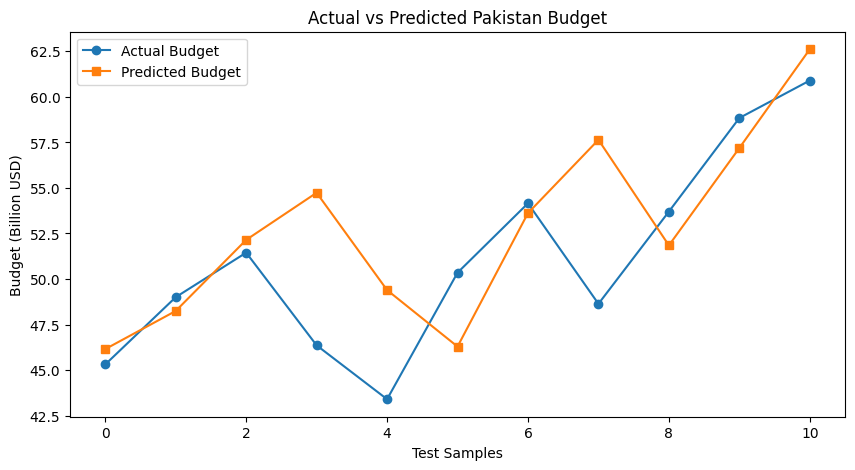

In [44]:
# MODEL EVALUATION ON TESTING DATA visualize actual vs predicted budget

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, marker="o", label="Actual Budget")
plt.plot(y_pred, marker="s", label="Predicted Budget")

plt.title("Actual vs Predicted Pakistan Budget")
plt.xlabel("Test Samples")
plt.ylabel("Budget (Billion USD)")
plt.legend()

plt.show()

In [45]:
# get real world prediction

sample = X.iloc[[0]]

prediction = lr.predict(sample)

print("Predicted Budget:", prediction[0])
print("Actual Budget   :", y.iloc[0])

Predicted Budget: 2.4153667229438724
Actual Budget   : 1.426


In [46]:
# save model comparison

comparison = pd.DataFrame({
    "Actual Budget": y_test,
    "Predicted Budget": y_pred
})

comparison

,Actual Budget,Predicted Budget
43,45.308,46.152343
44,49.002,48.245520
45,51.447,52.148765
46,46.359,54.736842
47,43.400,49.392845
48,50.347,46.290636
49,54.157,53.619214
50,48.638,57.644604
51,53.703,51.846774
52,58.841,57.193650


In [48]:
# save modified dataset

final_dataset = X.copy()
final_dataset["Total_Budget_Billions_USD"] = y
final_dataset.to_csv("pakistan_budget_processed.csv", index=False)

final_dataset.head()

,Year,Previous_Total_Budget,Defense_Percentage,Education_Percentage,Health_Percentage,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,Administration_and_Others_Percentage,Total_Budget_Billions_USD
0,1973,2.103,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96,1.426
1,1974,1.426,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96,1.988
2,1975,1.988,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96,2.508
3,1976,2.508,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96,2.941
4,1977,2.941,25.1,7.8,6.26,16.75,8.38,8.38,8.38,13.96,3.378


In [51]:
import os

file_to_delete = "pakistan_budget_predictor.pkl"
if os.path.exists(file_to_delete):
    os.remove(file_to_delete)
    print(f"File '{file_to_delete}' deleted successfully.")
else:
    print(f"File '{file_to_delete}' does not exist.")

File 'pakistan_budget_predictor.pkl' deleted successfully.


In [50]:
import os

# List all .pkl files in the current directory
pkl_files = [f for f in os.listdir('.') if f.endswith('.pkl')]
print("Saved .pkl files:", pkl_files)

Saved .pkl files: ['feature_columns.pkl', 'Pakistan_budget_predictor.pkl', 'pakistan_budget_predictor.pkl']


In [ ]:
### This project developed a machine learning model to predict Pakistan's annual government budget estimates using historical budget data from 1972–2026.

### After comparing different regression algorithms, Linear Regression was selected as the final model due to its stable performance and interpretability.

### The trained model predicts the next year's total budget estimate, while the expected budget growth percentage is calculated from the predicted budget and the previous year's budget.

### The trained model was exported using Joblib and is ready for deployment as a Streamlit web application.